# Phase 10 — Final Cross-Project Summary

Pulls together **every trained model evaluated so far across Phases 1-9** into one place:
overall rankings, accuracy-vs-size Pareto fronts, quantization robustness, detection/segmentation
transfer, and the Phase 6 hardware-profiling headline finding.

This is a **synthesis notebook only** — no training, no new `ml/` code. Every number here is
loaded from artifacts each phase's own notebook already produced (`*_summary.json` files and
`*_comparison.csv` tables). See each phase's own notebook (`notebooks/phase_{1..9}_*/`) for the
detailed per-phase analysis and hypothesis testing this summarizes.

**Scope note:** classification (Phases 1-4, 8, 9) shares one top-1/top-5 accuracy metric on Tiny
ImageNet-200 and is merged into a single ranking. Detection (mAP) and segmentation (mIoU) use
different metrics on a different dataset (PASCAL VOC) and are kept as separate sections — they
are not comparable to the classification top-1 numbers or to each other.

## Configuration

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until the repository root is found."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "models").exists() and (candidate / "results").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))  # so `import ml` resolves regardless of kernel cwd
print(f"Project root: {PROJECT_ROOT}")

RESULTS_ROOT = PROJECT_ROOT / "results"
RESULTS_DIR = RESULTS_ROOT / "phase_10_final_summary"
FIGURES_DIR = RESULTS_ROOT / "figures_generated" / "phase_10_final_summary"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from ml.plotting import apply_report_style, label_bars
apply_report_style()

# One consistent color per phase, in first-seen order, reused across every chart below.
PHASE_CMAP = plt.get_cmap("tab10")
def phase_colors_for(phases: pd.Series, order: list[str]) -> list:
    return [PHASE_CMAP(order.index(p) % 10) if p in order else "#999999" for p in phases]


Project root: /home/rafael/Documents/alexnet_rafael


/home/rafael/Documents/alexnet_rafael/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Classification Results (Phases 1-4, 8, 9)

Phases 1-4's models are read straight from the per-model `*_summary.json` files each training
notebook already writes (the `make_run_summary` schema) — `experiment_summary.json` (phase-level,
not per-model) and `*_compression_summary.json` (Phase 4's compression-ablation reruns of an
existing architecture, not a new one) are excluded so the ranking doesn't show duplicate/confusing
rows. Phase 9's bypass-ablation model lives under `outputs/pcad/` instead (git-ignored PCAD
output), so it's globbed separately. Phase 8 already has one aggregated CSV with the same column
family.

In [2]:
def load_summary_jsons(root: Path, phase_label: str) -> pd.DataFrame:
    """Every *_summary.json under root, excluding phase-level / compression-ablation ones."""
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for path in sorted(root.rglob("*_summary.json")):
        if path.name == "experiment_summary.json" or path.name.endswith("_compression_summary.json"):
            continue
        try:
            rows.append(json.loads(path.read_text()))
        except Exception as e:
            print(f"[skip] {path}: {e}")
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df["phase"] = phase_label  # make_run_summary doesn't record this itself -- tag it from the source dir
    if "model_name" in df.columns and "epochs" in df.columns:
        # Keep the most-trained (highest-epoch) run per model_name in case of reruns.
        df = df.sort_values("epochs").drop_duplicates(subset="model_name", keep="last").reset_index(drop=True)
    return df


PHASE_DIRS = {
    "Phase 1 — Baselines": RESULTS_ROOT / "phase_1_baseline_training",
    "Phase 2 — AlexNet Variants": RESULTS_ROOT / "phase_2_kernel_restriction_training",
    "Phase 3 — Compensation": RESULTS_ROOT / "phase_3_compensation_and_hybrids_training",
    "Phase 4 — Final Architecture": RESULTS_ROOT / "phase_4_compression_and_final_architecture_training",
    "Phase 9 — PCAD Bypass Ablation": PROJECT_ROOT / "outputs" / "pcad" / "phase_9_bypass_ablation",
}
PHASE8_CSV = RESULTS_ROOT / "phase_8_efficient_vit_hybrid_attention_analysis" / "phase8_comparison.csv"

frames = [load_summary_jsons(d, label) for label, d in PHASE_DIRS.items()]

if PHASE8_CSV.exists():
    df_phase8 = pd.read_csv(PHASE8_CSV)
    if "phase" not in df_phase8.columns:
        df_phase8["phase"] = "Phase 8 — Efficient ViT / Hybrid-Attention"
    frames.append(df_phase8)
else:
    print(f"[skip] {PHASE8_CSV} not found")

SHARED_COLS = [
    "phase", "model_name", "fp32_top1", "fp32_top5", "int8_top1", "int8_top5",
    "quantization_drop_top1", "fp32_size_mb", "int8_size_mb", "params_m", "macs",
    "fp32_latency_ms_per_image", "fp32_throughput_img_per_s",
    "param_efficiency_top1_per_m", "total_training_time_s",
    "avg_epoch_time_s", "peak_gpu_mem_mb",  # computed by make_run_summary but unused until now
]
frames = [f for f in frames if not f.empty]
df_all_classification = pd.concat(
    [f[[c for c in SHARED_COLS if c in f.columns]] for f in frames],
    ignore_index=True,
) if frames else pd.DataFrame(columns=SHARED_COLS)
df_all_classification = df_all_classification.drop_duplicates(subset="model_name", keep="last").reset_index(drop=True)

PHASE_ORDER = sorted(df_all_classification["phase"].dropna().unique().tolist()) if not df_all_classification.empty else []

print(f"Loaded {len(df_all_classification)} classification models across {len(PHASE_ORDER)} phases.")
display(df_all_classification[["phase", "model_name", "fp32_top1", "int8_top1", "quantization_drop_top1",
                                "fp32_size_mb", "params_m"]].sort_values("fp32_top1", ascending=False).reset_index(drop=True))


Loaded 31 classification models across 6 phases.


,phase,model_name,fp32_top1,int8_top1,quantization_drop_top1,fp32_size_mb,params_m
0,Phase 1 — Baselines,mobilenetv2,57.995582,NaN,NaN,28.751925,2.480072
1,Phase 1 — Baselines,resnet18_tv,53.913635,NaN,NaN,129.208681,11.279112
2,Phase 1 — Baselines,vgg_style,51.814806,51.188743,0.626063,27.584812,2.405288
3,Phase 4 — Final Architecture,alexnet_final_fire_residual,49.793291,49.201027,0.592265,8.093657,0.698664
4,Phase 9 — PCAD Bypass Ablation,alexnet_fire_bypass,49.026531,49.864638,-0.838107,5.990506,0.516152
5,Phase 3 — Compensation,alexnet_residual,48.012939,47.273704,0.739235,694.414034,60.670280
6,Phase 2 — AlexNet Variants,alexnet_small_kernel,45.836565,36.162835,9.673730,18.353315,1.602376
7,Phase 2 — AlexNet Variants,alexnet_stacked,45.219755,42.309719,2.910036,692.255035,60.483976
8,Phase 4 — Final Architecture,alexnet_final_bottleneck_residual,45.099601,45.980674,-0.881073,6.653960,0.571304
9,Phase 3 — Compensation,alexnet_bottleneck,44.622979,44.539082,0.083897,4.491745,0.385000


## Load Detection & Segmentation Results (Phase 7)

Loaded straight from the CSVs `notebooks/phase_7_detection_segmentation_analysis/phase7_results_analysis.ipynb`
already produced. Only `status == "complete"` and `post_fix == True` rows are kept (`post_fix`
marks runs built after the anchor-recall bug fix — see that notebook for details).

In [3]:
def load_phase7_csv(name: str) -> pd.DataFrame:
    path = RESULTS_ROOT / "phase_7_detection_segmentation_analysis" / name
    if not path.exists():
        print(f"[skip] {path} not found")
        return pd.DataFrame()
    df = pd.read_csv(path)
    if "status" in df.columns:
        df = df[df["status"] == "complete"]
    if "post_fix" in df.columns:
        df = df[df["post_fix"] == True]  # noqa: E712
    return df.reset_index(drop=True)


df_detection = load_phase7_csv("phase7_comparison.csv")
df_segmentation = load_phase7_csv("phase7_seg_comparison.csv")
print(f"Detection runs (complete, post-fix): {len(df_detection)}")
print(f"Segmentation runs (complete, post-fix): {len(df_segmentation)}")


Detection runs (complete, post-fix): 18
Segmentation runs (complete, post-fix): 9


## Load Hardware Profiling Highlights (Phase 6)

Phase 6 measures latency/power on already-trained Phase 1-4 models rather than training new ones, so it doesn't add rows to the classification ranking above — just a compute-efficiency-by-kernel-group check (Winograd evidence) and a latency/accuracy view. See `notebooks/phase_6_hardware_profiling_analysis/hardware_profiling_phase6.ipynb` for the full H1-H4 hypothesis analysis.

In [4]:
PHASE6_DIR = RESULTS_ROOT / "phase_6_hardware_profiling_analysis"

def load_phase6_csv(name: str) -> pd.DataFrame:
    path = PHASE6_DIR / name
    if not path.exists():
        print(f"[skip] {path} not found")
        return pd.DataFrame()
    return pd.read_csv(path)


df_winograd_evidence = load_phase6_csv("h1_winograd_evidence.csv")
df_latency_pareto = load_phase6_csv("h3_latency_pareto.csv")
print(f"Winograd evidence rows: {len(df_winograd_evidence)}")
print(f"Latency/accuracy rows: {len(df_latency_pareto)}")


Winograd evidence rows: 6
Latency/accuracy rows: 20


## 1. All-Model FP32 Top-1 Ranking

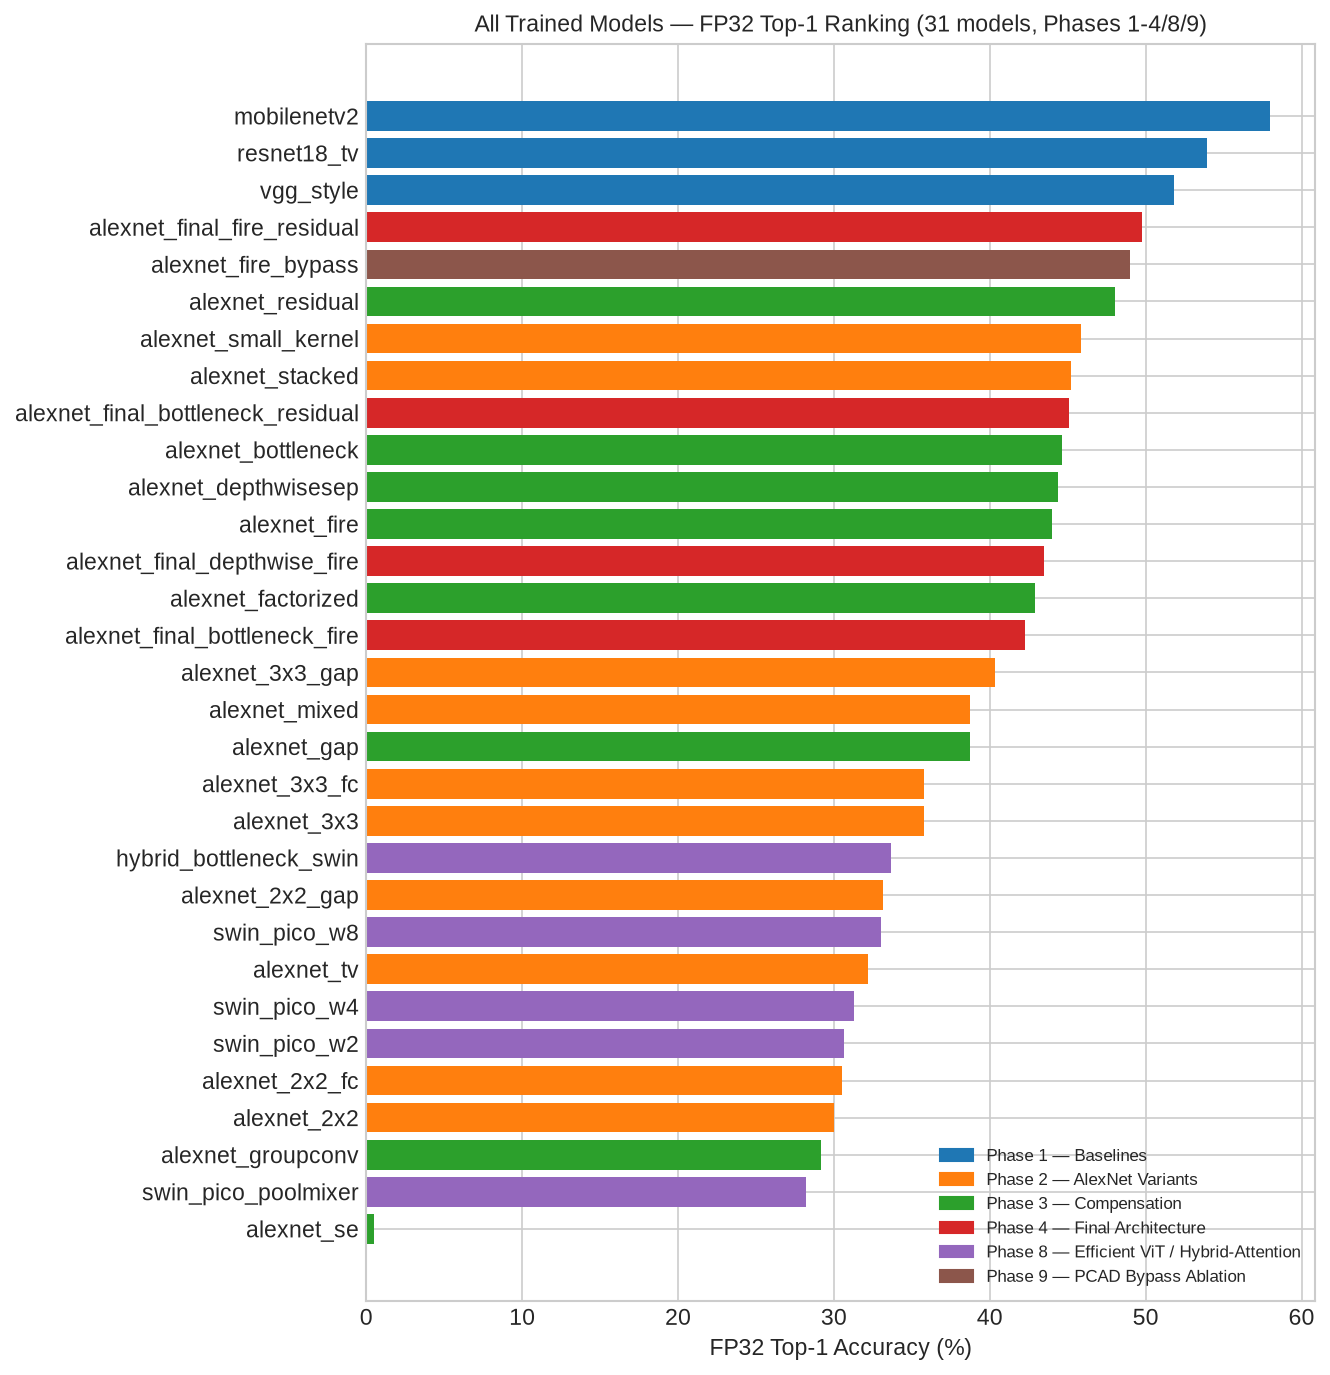

In [5]:
if not df_all_classification.empty:
    rank_df = df_all_classification[df_all_classification["fp32_top1"].notna()] \
        .sort_values("fp32_top1").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(rank_df))))
    ax.barh(rank_df["model_name"], rank_df["fp32_top1"],
            color=phase_colors_for(rank_df["phase"], PHASE_ORDER))
    ax.set_xlabel("FP32 Top-1 Accuracy (%)")
    ax.set_title(f"All Trained Models — FP32 Top-1 Ranking ({len(rank_df)} models, Phases 1-4/8/9)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=PHASE_CMAP(i % 10)) for i in range(len(PHASE_ORDER))]
    ax.legend(handles, PHASE_ORDER, loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "all_models_fp32_ranking.png")
    plt.show()
else:
    print("[skip] No classification data loaded")


## 2. Accuracy vs. Model Size — Pareto Frontier (All Classification Models)

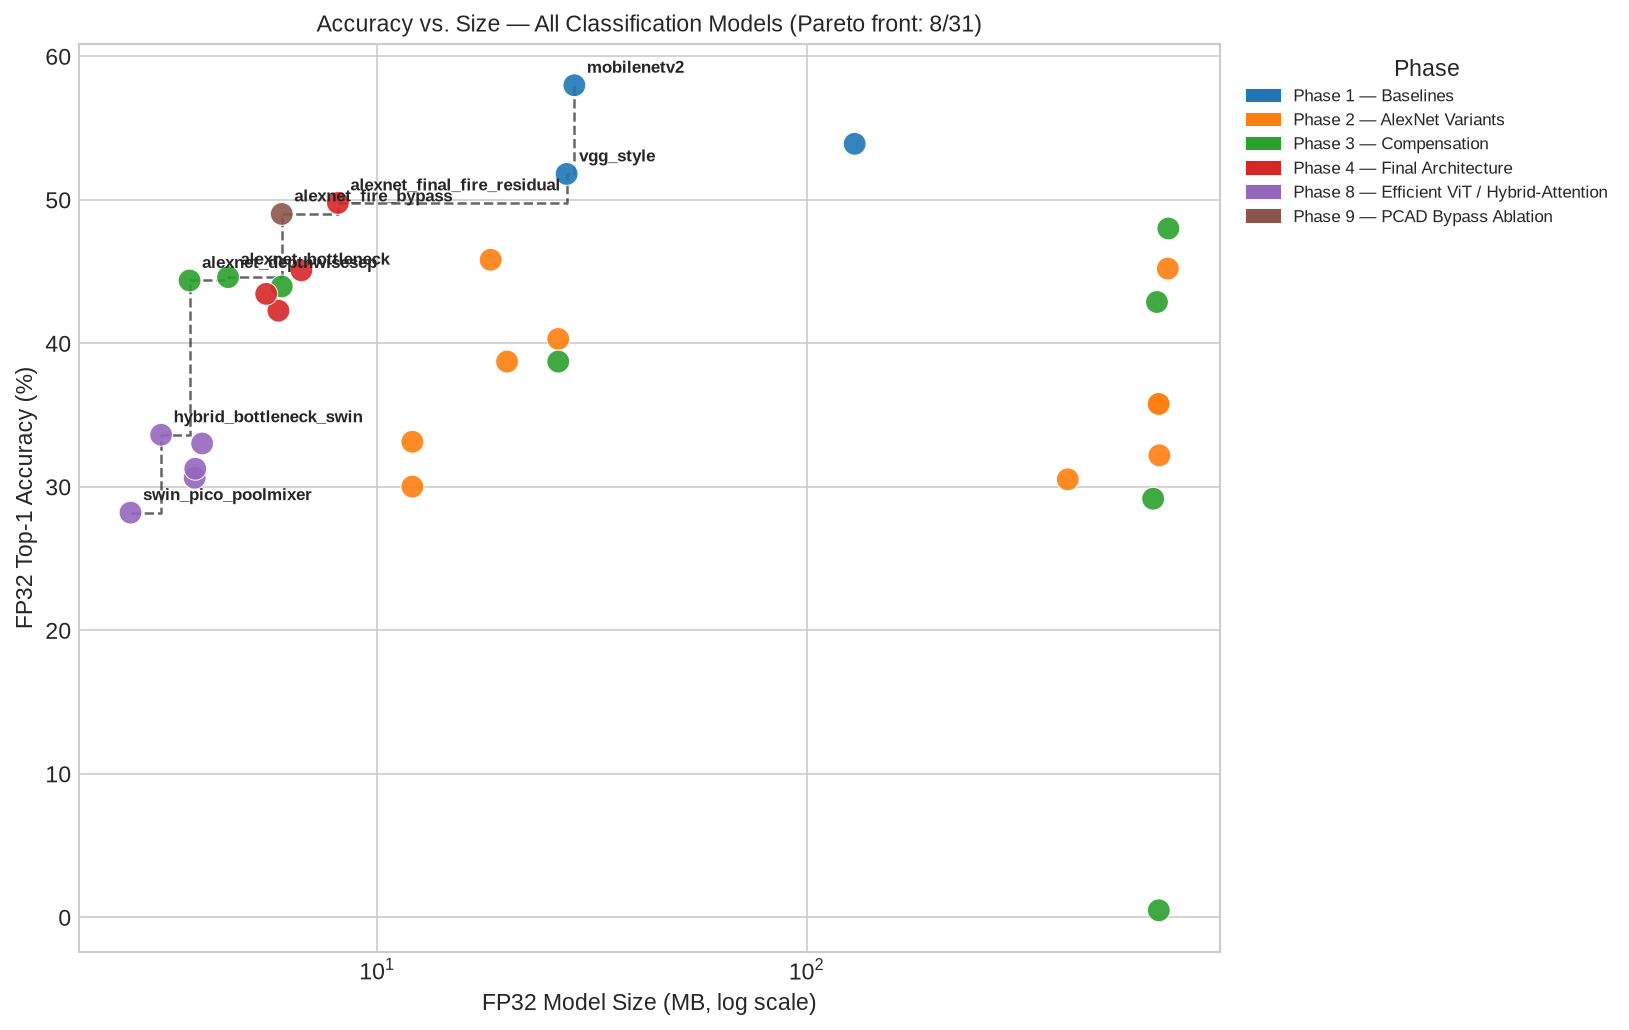

In [6]:
def pareto_front_mask(xs, ys):
    """Boolean mask: True if point is Pareto-optimal (minimize x, maximize y)."""
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    dominated = np.zeros(len(xs), dtype=bool)
    for i in range(len(xs)):
        for j in range(len(xs)):
            if i != j and xs[j] <= xs[i] and ys[j] >= ys[i] and (xs[j] < xs[i] or ys[j] > ys[i]):
                dominated[i] = True
                break
    return ~dominated


df_size = df_all_classification[df_all_classification["fp32_top1"].notna()
                                 & df_all_classification["fp32_size_mb"].notna()].copy()
if len(df_size) >= 2:
    mask = pareto_front_mask(df_size["fp32_size_mb"].values, df_size["fp32_top1"].values)
    pf = df_size[mask].sort_values("fp32_size_mb")

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(df_size["fp32_size_mb"], df_size["fp32_top1"],
               c=phase_colors_for(df_size["phase"], PHASE_ORDER), s=120,
               edgecolors="white", lw=0.5, alpha=0.9, zorder=3)
    ax.step(pf["fp32_size_mb"], pf["fp32_top1"], where="post",
            color="black", lw=1.2, ls="--", alpha=0.6, zorder=2)
    for _, row in pf.iterrows():
        ax.annotate(row["model_name"], (row["fp32_size_mb"], row["fp32_top1"]),
                    xytext=(6, 6), textcoords="offset points", fontsize=8, fontweight="bold")
    ax.set_xscale("log")
    ax.set_xlabel("FP32 Model Size (MB, log scale)")
    ax.set_ylabel("FP32 Top-1 Accuracy (%)")
    ax.set_title(f"Accuracy vs. Size — All Classification Models (Pareto front: {len(pf)}/{len(df_size)})")
    handles = [plt.Rectangle((0, 0), 1, 1, color=PHASE_CMAP(i % 10)) for i in range(len(PHASE_ORDER))]
    ax.legend(handles, PHASE_ORDER, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, title="Phase")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "all_models_accuracy_vs_size_pareto.png", bbox_inches="tight")
    plt.show()
else:
    print("[skip] Not enough models with size + accuracy")


## 3. Quantization Drop (FP32 → INT8) — All Classification Models

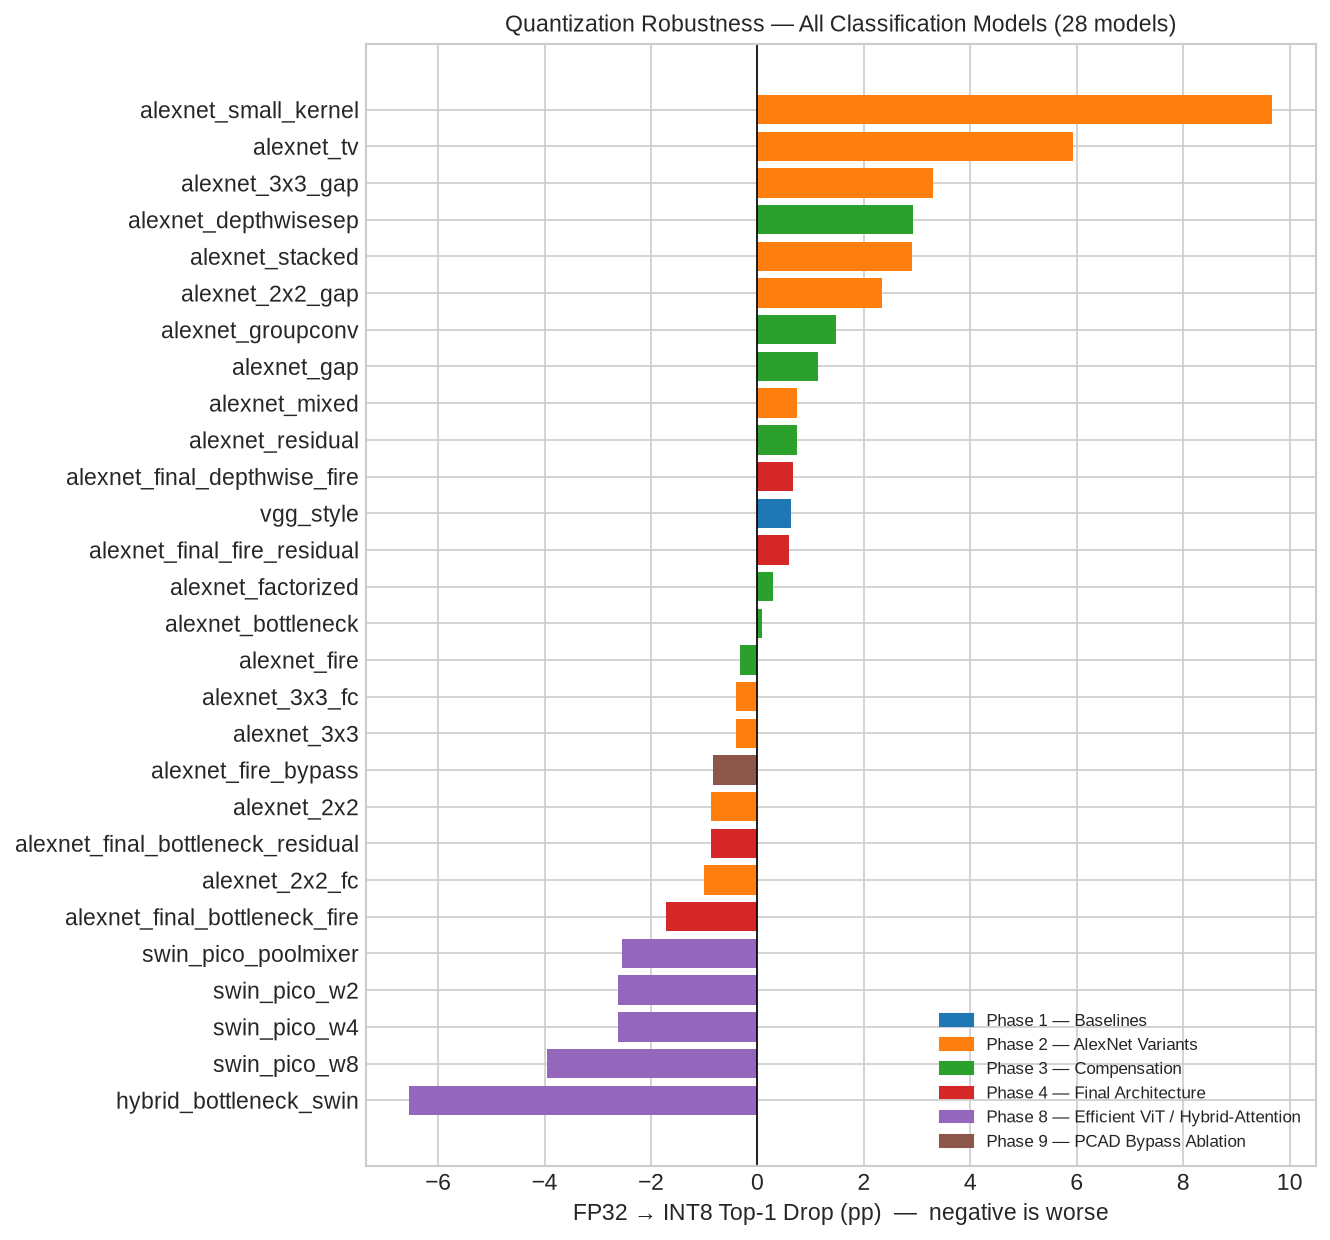

In [7]:
df_drop = df_all_classification[df_all_classification["quantization_drop_top1"].notna()] \
    .sort_values("quantization_drop_top1").reset_index(drop=True)
if not df_drop.empty:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(df_drop))))
    ax.barh(df_drop["model_name"], df_drop["quantization_drop_top1"],
            color=phase_colors_for(df_drop["phase"], PHASE_ORDER))
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("FP32 → INT8 Top-1 Drop (pp)  —  negative is worse")
    ax.set_title(f"Quantization Robustness — All Classification Models ({len(df_drop)} models)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=PHASE_CMAP(i % 10)) for i in range(len(PHASE_ORDER))]
    ax.legend(handles, PHASE_ORDER, loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "all_models_quantization_drop.png")
    plt.show()
else:
    print("[skip] No quantization-drop data")


## 3b. Training Efficiency — Avg Epoch Time (All Classification Models)

`avg_epoch_time_s` is computed by `make_run_summary` for every run but wasn't previously surfaced
here. Per-epoch *curves* (loss/accuracy over training, LR schedule) are a different notebook —
see `training_dynamics.ipynb` — since the source data (raw logs/TensorBoard events) and only
partial phase coverage make it a poor fit for this notebook's one-row-per-model tables.

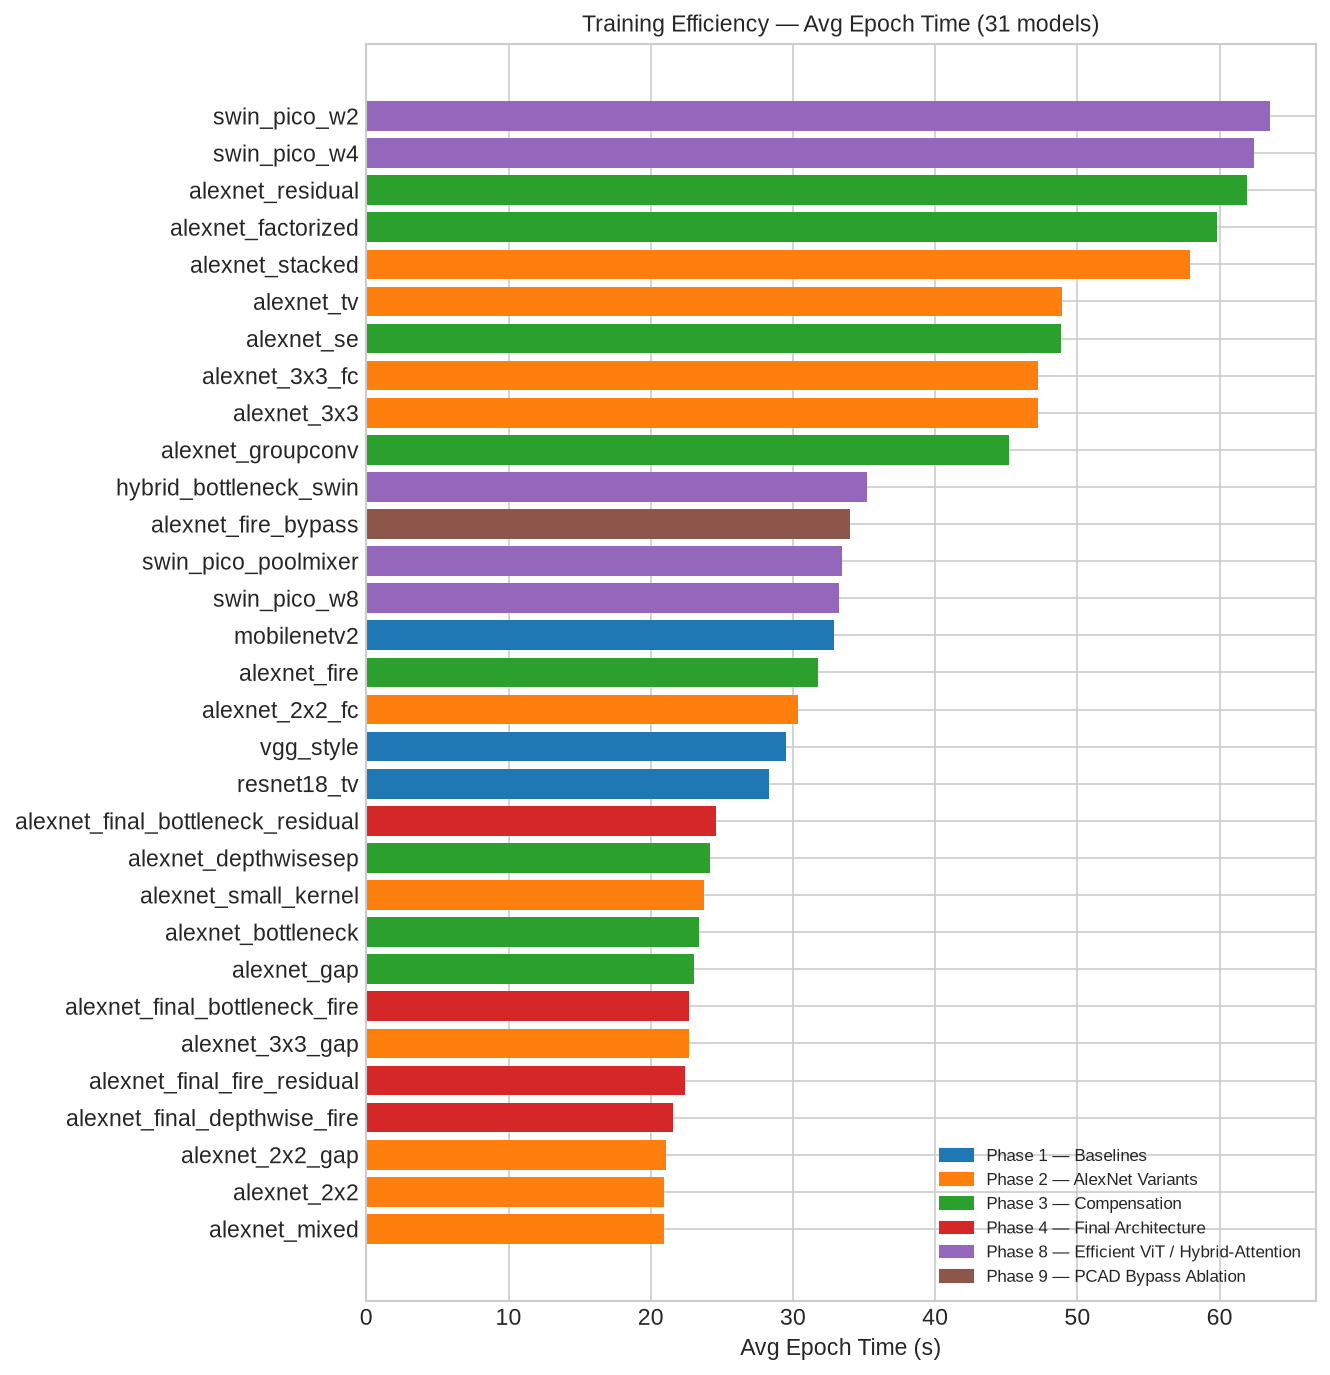

In [8]:
df_epoch_time = df_all_classification[df_all_classification["avg_epoch_time_s"].notna()] \
    .sort_values("avg_epoch_time_s").reset_index(drop=True)
if not df_epoch_time.empty:
    fig, ax = plt.subplots(figsize=(9, max(4, 0.3 * len(df_epoch_time))))
    ax.barh(df_epoch_time["model_name"], df_epoch_time["avg_epoch_time_s"],
            color=phase_colors_for(df_epoch_time["phase"], PHASE_ORDER))
    ax.set_xlabel("Avg Epoch Time (s)")
    ax.set_title(f"Training Efficiency — Avg Epoch Time ({len(df_epoch_time)} models)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=PHASE_CMAP(i % 10)) for i in range(len(PHASE_ORDER))]
    ax.legend(handles, PHASE_ORDER, loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "all_models_avg_epoch_time.png")
    plt.show()
else:
    print("[skip] No avg_epoch_time_s data")


## 4. Detection — mAP vs. Model Size (Phase 7)

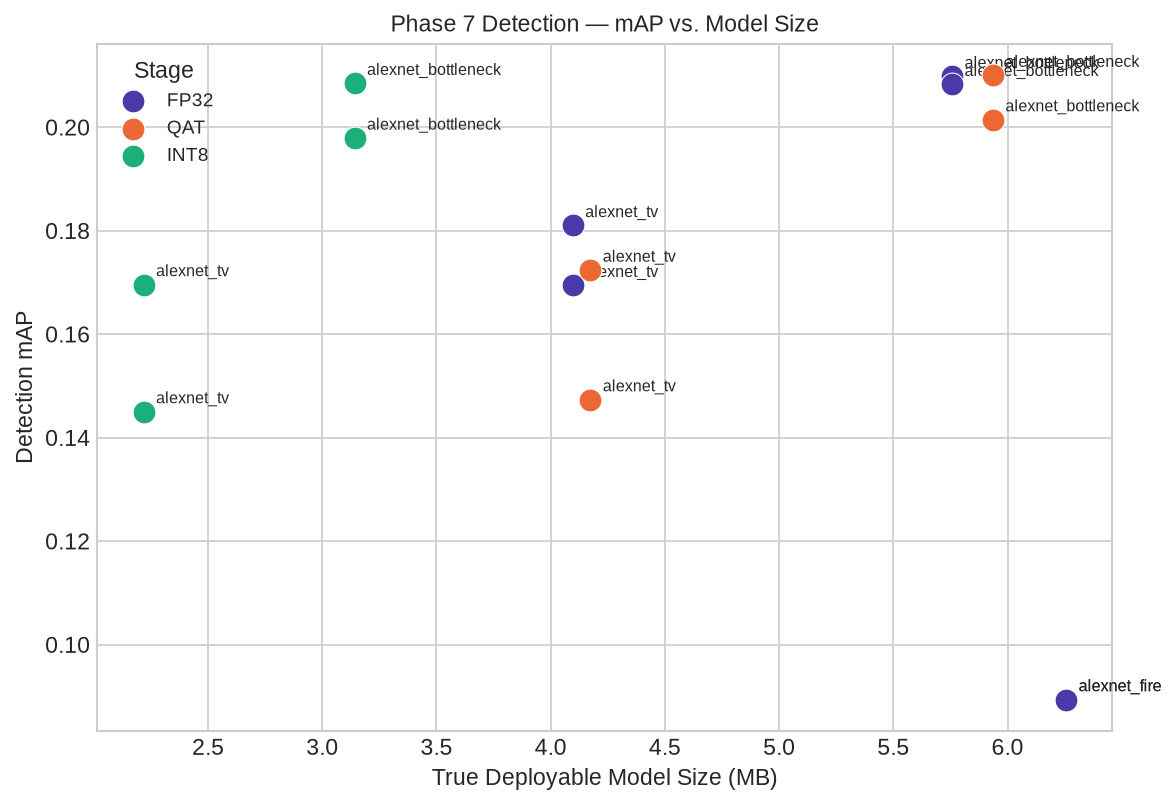

In [9]:
STAGE_COLORS = {"fp32": "#4a3aa7", "qat": "#eb6834", "int8": "#1baf7a"}

if not df_detection.empty and "true_size_mb" in df_detection.columns:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for stage, color in STAGE_COLORS.items():
        sv = df_detection[(df_detection["stage"] == stage) & df_detection["best_val_mAP"].notna()
                           & df_detection["true_size_mb"].notna()]
        if sv.empty:
            continue
        ax.scatter(sv["true_size_mb"], sv["best_val_mAP"], color=color, s=120,
                   label=stage.upper(), edgecolors="white", lw=0.5, zorder=3)
        for _, row in sv.iterrows():
            ax.annotate(row["model"], (row["true_size_mb"], row["best_val_mAP"]),
                        xytext=(6, 4), textcoords="offset points", fontsize=7.5)
    ax.set_xlabel("True Deployable Model Size (MB)")
    ax.set_ylabel("Detection mAP")
    ax.set_title("Phase 7 Detection — mAP vs. Model Size")
    ax.legend(fontsize=9, title="Stage")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "detection_map_vs_size.png")
    plt.show()
else:
    print("[skip] No detection size/accuracy data")


## 5. Segmentation — mIoU vs. Model Size (Phase 7)

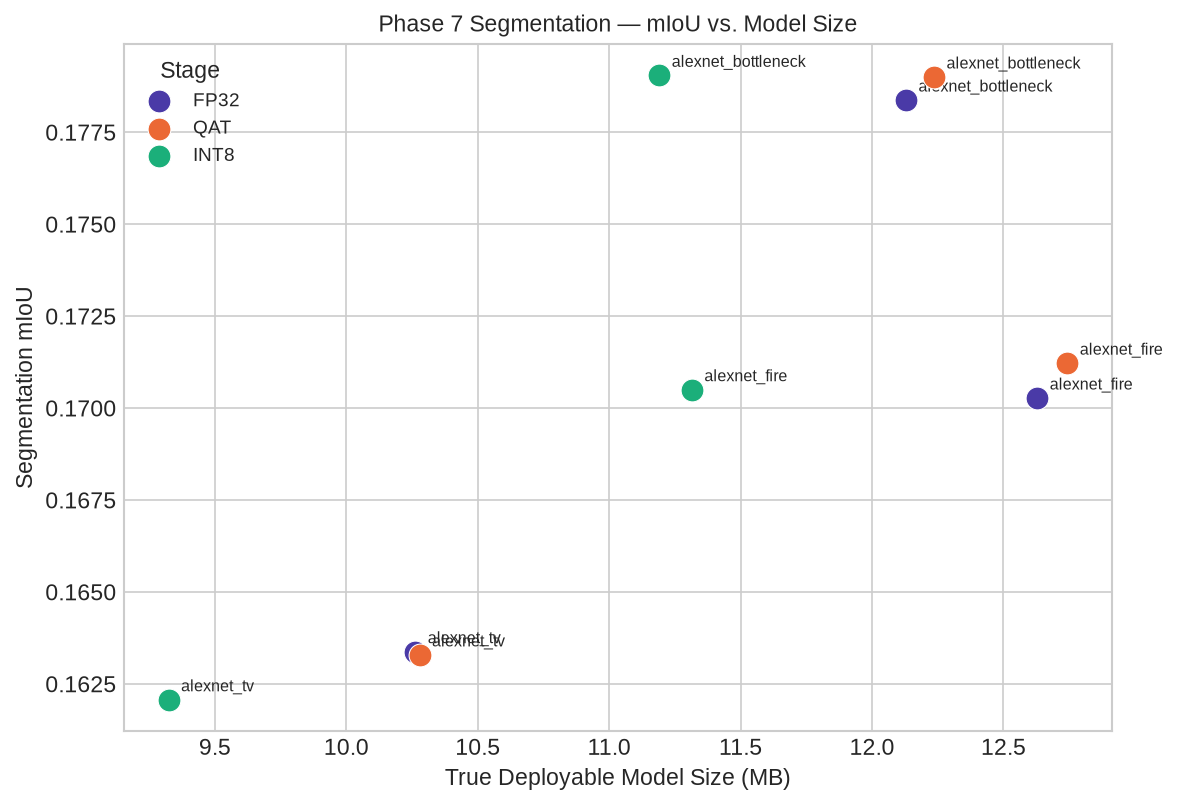

In [10]:
if not df_segmentation.empty and "true_size_mb" in df_segmentation.columns:
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for stage, color in STAGE_COLORS.items():
        sv = df_segmentation[(df_segmentation["stage"] == stage) & df_segmentation["best_val_mIoU"].notna()
                              & df_segmentation["true_size_mb"].notna()]
        if sv.empty:
            continue
        ax.scatter(sv["true_size_mb"], sv["best_val_mIoU"], color=color, s=120,
                   label=stage.upper(), edgecolors="white", lw=0.5, zorder=3)
        for _, row in sv.iterrows():
            ax.annotate(row["model"], (row["true_size_mb"], row["best_val_mIoU"]),
                        xytext=(6, 4), textcoords="offset points", fontsize=7.5)
    ax.set_xlabel("True Deployable Model Size (MB)")
    ax.set_ylabel("Segmentation mIoU")
    ax.set_title("Phase 7 Segmentation — mIoU vs. Model Size")
    ax.legend(fontsize=9, title="Stage")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "segmentation_miou_vs_size.png")
    plt.show()
else:
    print("[skip] No segmentation size/accuracy data")


## 6. Hardware Profiling Highlights (Phase 6)

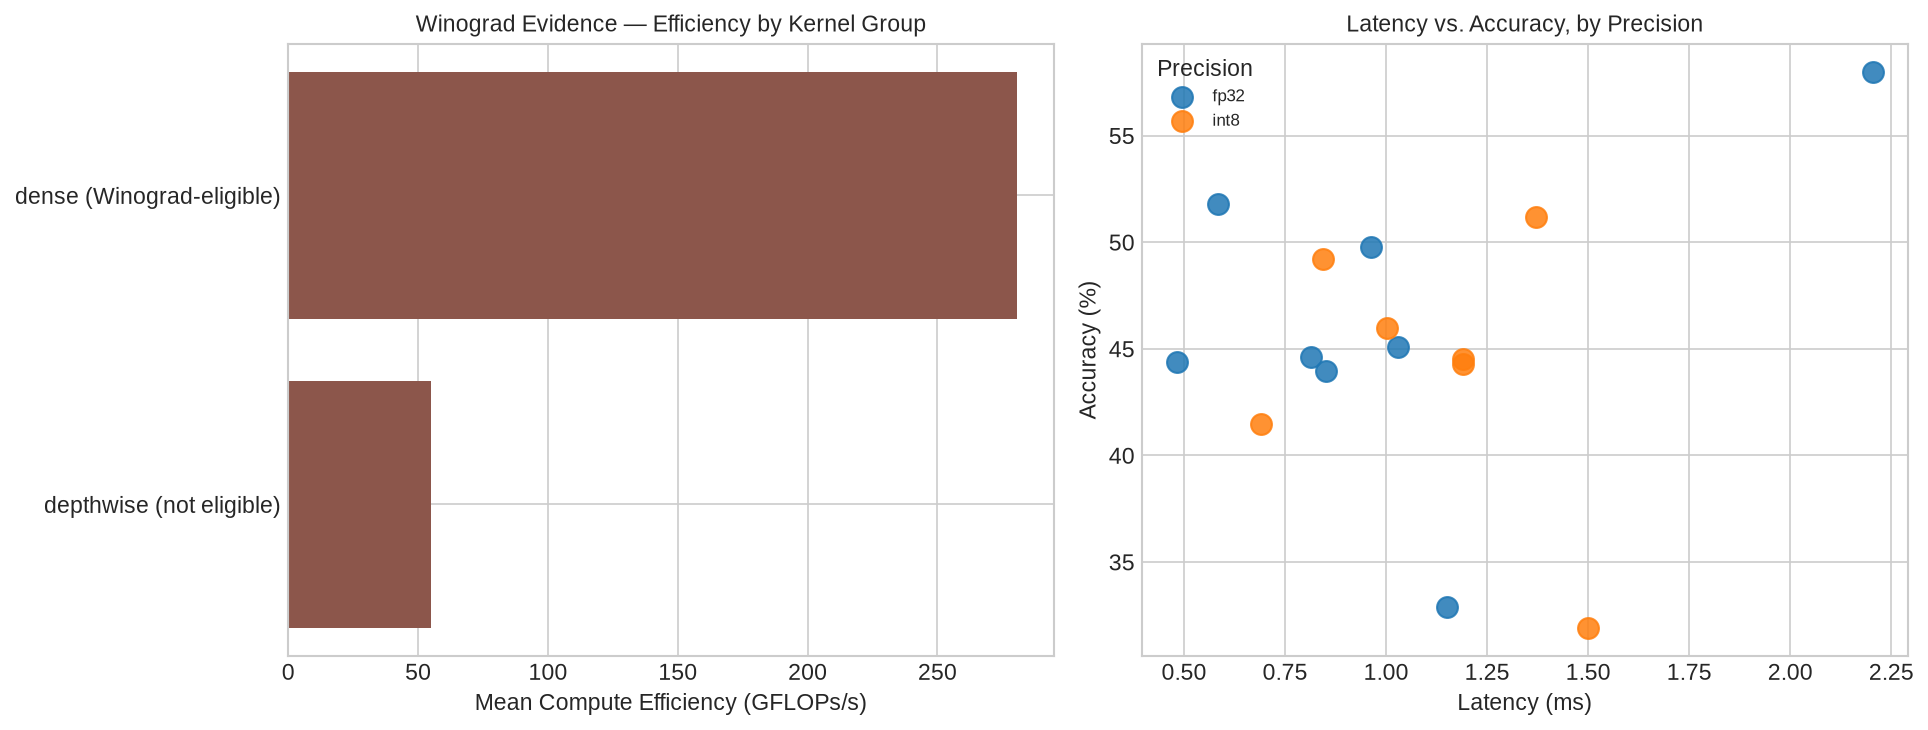

In [11]:
if not df_winograd_evidence.empty or not df_latency_pareto.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    if not df_winograd_evidence.empty and "group" in df_winograd_evidence.columns:
        g = df_winograd_evidence.groupby("group")["compute_efficiency_gflops_s"].mean().sort_values()
        axes[0].barh(g.index, g.values, color=PHASE_CMAP(5))
        axes[0].set_xlabel("Mean Compute Efficiency (GFLOPs/s)")
        axes[0].set_title("Winograd Evidence — Efficiency by Kernel Group")
    else:
        axes[0].axis("off")
        axes[0].set_title("[skip] No Winograd evidence data")

    if not df_latency_pareto.empty and all(c in df_latency_pareto.columns for c in ("latency_ms", "accuracy")):
        for precision in df_latency_pareto["precision"].dropna().unique():
            sv = df_latency_pareto[df_latency_pareto["precision"] == precision]
            axes[1].scatter(sv["latency_ms"], sv["accuracy"], s=100, label=str(precision), alpha=0.85)
        axes[1].set_xlabel("Latency (ms)")
        axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_title("Latency vs. Accuracy, by Precision")
        axes[1].legend(fontsize=8, title="Precision")
    else:
        axes[1].axis("off")
        axes[1].set_title("[skip] No latency/accuracy data")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "phase6_hardware_highlights.png")
    plt.show()
else:
    print("[skip] No Phase 6 data loaded")


## Master Tables

In [12]:
print("=== Classification — all models, ranked by FP32 top-1 ===")
display(df_all_classification.sort_values("fp32_top1", ascending=False).reset_index(drop=True))

if not df_detection.empty:
    print("\n=== Detection — ranked by mAP ===")
    display(df_detection.sort_values("best_val_mAP", ascending=False).reset_index(drop=True))

if not df_segmentation.empty:
    print("\n=== Segmentation — ranked by mIoU ===")
    display(df_segmentation.sort_values("best_val_mIoU", ascending=False).reset_index(drop=True))


=== Classification — all models, ranked by FP32 top-1 ===


,phase,model_name,fp32_top1,fp32_top5,int8_top1,int8_top5,quantization_drop_top1,fp32_size_mb,int8_size_mb,params_m,macs,fp32_latency_ms_per_image,fp32_throughput_img_per_s,param_efficiency_top1_per_m,total_training_time_s,avg_epoch_time_s,peak_gpu_mem_mb
0,Phase 1 — Baselines,mobilenetv2,57.995582,81.514984,NaN,NaN,NaN,28.751925,NaN,2.480072,25799936,0.132181,7565.409311,23.414643,1087.841990,32.872253,536.681641
1,Phase 1 — Baselines,resnet18_tv,53.913635,77.797484,NaN,NaN,NaN,129.208681,NaN,11.279112,148555776,0.127640,7834.536194,4.785838,598.386289,28.283485,541.729004
2,Phase 1 — Baselines,vgg_style,51.814806,75.881696,51.188743,75.520074,0.626063,27.584812,2.376703,2.405288,231086080,0.130711,7650.439345,21.556670,2009.612514,29.492009,504.485352
3,Phase 4 — Final Architecture,alexnet_final_fire_residual,49.793291,74.802184,49.201027,74.387586,0.592265,8.093657,0.746309,0.698664,55236608,0.089877,11126.364083,71.250272,1729.113626,22.418562,142.385254
4,Phase 9 — PCAD Bypass Ablation,alexnet_fire_bypass,49.026531,73.936284,49.864638,74.564046,-0.838107,5.990506,0.554306,0.516152,177670144,0.200522,4986.993365,97.761900,5918.036756,34.044578,402.373535
5,Phase 3 — Compensation,alexnet_residual,48.012939,73.108339,47.273704,72.499549,0.739235,694.414034,58.102711,60.670280,520749056,0.155194,6443.549014,0.792151,638.534984,61.899157,1182.288574
6,Phase 2 — AlexNet Variants,alexnet_small_kernel,45.836565,71.076936,36.162835,61.603314,9.673730,18.353315,1.561041,1.602376,460179456,0.152415,6561.013498,28.607518,24.232722,23.744635,1038.208496
7,Phase 2 — AlexNet Variants,alexnet_stacked,45.219755,70.960724,42.309719,68.345517,2.910036,692.255035,57.941553,60.483976,506085376,0.142897,6998.055508,0.749124,896.432341,57.935961,2011.450684
8,Phase 4 — Final Architecture,alexnet_final_bottleneck_residual,45.099601,71.151185,45.980674,72.328943,-0.881073,6.653960,0.637690,0.571304,54175744,0.089775,11138.912264,78.977217,934.406803,24.554570,187.150879
9,Phase 3 — Compensation,alexnet_bottleneck,44.622979,71.036339,44.539082,71.014529,0.083897,4.491745,0.431780,0.385000,39512064,0.105113,9513.546980,116.051948,27.804998,23.384645,146.848145



=== Detection — ranked by mAP ===


,run_dir,model,stage,pretrained,git_hash,post_fix,status,best_val_mAP,best_val_mAP50,best_epoch,total_time_s,params_m,macs,model_size_mb,true_size_mb,latency_ms_per_image
0,ssd_alexnet_bottleneck_qat_phase7_detection,alexnet_bottleneck,qat,False,9476ae089cd9b547b3796198d0a55ee941b1afeb,True,complete,0.210037,0.477331,98.0,85780.215132,1.532362,4.465787e+09,6.158990,5.935833,8.025387
1,ssd_alexnet_bottleneck_fp32_phase7_detection,alexnet_bottleneck,fp32,False,baa3528eb2799b9aa61a0cbfb918a6eed1f7f758,True,complete,0.209839,0.474579,549.0,107015.732150,1.532362,4.465787e+09,5.964869,5.757147,8.025433
2,ssd_alexnet_bottleneck_int8_phase7_detection,alexnet_bottleneck,int8,False,9476ae089cd9b547b3796198d0a55ee941b1afeb,True,complete,0.208474,0.478349,NaN,NaN,1.532362,NaN,3.347330,3.141130,NaN
3,ssd_alexnet_bottleneck_fp32_pretrained_phase7_...,alexnet_bottleneck,fp32,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.208265,0.483414,709.0,201785.004607,1.532362,4.465787e+09,5.966902,5.757147,7.243327
4,ssd_alexnet_bottleneck_qat_pretrained_phase7_d...,alexnet_bottleneck,qat,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.201450,0.471706,24.0,65899.853478,1.532362,4.465787e+09,6.164181,5.935833,17.145327
5,ssd_alexnet_bottleneck_int8_pretrained_phase7_...,alexnet_bottleneck,int8,True,ee6438bf33d637832f3c2b0837bfb75417d374ed,True,complete,0.197899,0.467040,NaN,NaN,1.532362,NaN,3.349636,3.141130,NaN
6,ssd_alexnet_tv_fp32_pretrained_phase7_detection,alexnet_tv,fp32,True,bea59260c7ad2d65f731a2f4b20edbb75b5cc65e,True,complete,0.180991,0.398273,791.0,450336.319641,58.551722,1.835279e+09,223.424448,4.096243,10.233464
7,ssd_alexnet_tv_qat_pretrained_phase7_detection,alexnet_tv,qat,True,bea59260c7ad2d65f731a2f4b20edbb75b5cc65e,True,complete,0.172376,0.382056,93.0,43541.962705,58.551722,1.835279e+09,223.508148,4.173466,9.627961
8,ssd_alexnet_tv_int8_pretrained_phase7_detection,alexnet_tv,int8,True,bea59260c7ad2d65f731a2f4b20edbb75b5cc65e,True,complete,0.169582,0.378225,NaN,NaN,NaN,NaN,NaN,2.217573,NaN
9,ssd_alexnet_tv_fp32_phase7_detection,alexnet_tv,fp32,False,bea59260c7ad2d65f731a2f4b20edbb75b5cc65e,True,complete,0.169423,0.376673,927.0,414073.964501,58.551722,1.835279e+09,223.423273,4.096243,17.223595



=== Segmentation — ranked by mIoU ===


,run_dir,model,stage,git_hash,post_fix,status,best_val_mIoU,best_epoch,total_time_s,ckpt_size_mb,true_size_mb
0,seg_alexnet_bottleneck_int8_phase7_segmentation,alexnet_bottleneck,int8,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.179052,NaN,NaN,11.394001,11.190401
1,seg_alexnet_bottleneck_qat_phase7_segmentation,alexnet_bottleneck,qat,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.179007,5.0,786.405844,12.452831,12.235767
2,seg_alexnet_bottleneck_fp32_phase7_segmentation,alexnet_bottleneck,fp32,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.178380,84.0,1708.433631,12.334288,12.129004
3,seg_alexnet_fire_qat_phase7_segmentation,alexnet_fire,qat,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.171225,26.0,1754.565800,12.959681,12.742903
4,seg_alexnet_fire_int8_phase7_segmentation,alexnet_fire,int8,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.170503,NaN,NaN,11.517443,11.314466
5,seg_alexnet_fire_fp32_phase7_segmentation,alexnet_fire,fp32,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.170277,154.0,3903.773878,12.832815,12.628454
6,seg_alexnet_tv_fp32_phase7_segmentation,alexnet_tv,fp32,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.163380,99.0,2328.047420,229.587069,10.262274
7,seg_alexnet_tv_qat_phase7_segmentation,alexnet_tv,qat,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.163292,2.0,749.011189,229.604711,10.278409
8,seg_alexnet_tv_int8_phase7_segmentation,alexnet_tv,int8,713d1450ce2a0c7790c76c55a1059917a193c291,True,complete,0.162072,NaN,NaN,228.648062,9.323708


## Conclusions

Generated from the tables loaded above, so it stays correct as new Phase 8/9 results land — not a static write-up.

In [13]:
lines = []

if not df_all_classification.empty and df_all_classification["fp32_top1"].notna().any():
    m, p, v = df_all_classification.loc[df_all_classification["fp32_top1"].idxmax(), ["model_name", "phase", "fp32_top1"]]
    lines.append(f"- Best FP32 accuracy overall: **{m}** ({p}) at {v:.2f}% top-1.")

if not df_all_classification.empty and df_all_classification["fp32_top1"].notna().any() \
        and df_all_classification["fp32_size_mb"].notna().any():
    eff = df_all_classification[df_all_classification["fp32_top1"].notna()
                                 & df_all_classification["fp32_size_mb"].notna()].copy()
    eff["acc_per_mb"] = eff["fp32_top1"] / eff["fp32_size_mb"]
    best_eff = eff.loc[eff["acc_per_mb"].idxmax()]
    m, p, a, acc, sz = best_eff["model_name"], best_eff["phase"], best_eff["acc_per_mb"], best_eff["fp32_top1"], best_eff["fp32_size_mb"]
    lines.append(f"- Best accuracy-per-MB efficiency: **{m}** ({p}) at {a:.2f}%/MB ({acc:.2f}% in {sz:.2f} MB).")

if not df_all_classification.empty and df_all_classification["quantization_drop_top1"].notna().any():
    most_stable = df_all_classification.loc[df_all_classification["quantization_drop_top1"].idxmax()]
    m, p, d = most_stable["model_name"], most_stable["phase"], most_stable["quantization_drop_top1"]
    lines.append(f"- Most quantization-robust: **{m}** ({p}), FP32\u2192INT8 change of {d:+.2f}pp.")

if not df_detection.empty and df_detection["best_val_mAP"].notna().any():
    best_det = df_detection.loc[df_detection["best_val_mAP"].idxmax()]
    m, s, v = best_det["model"], best_det["stage"], best_det["best_val_mAP"]
    lines.append(f"- Best detection result: **{m}** ({s}) at {v:.3f} mAP.")

if not df_segmentation.empty and df_segmentation["best_val_mIoU"].notna().any():
    best_seg = df_segmentation.loc[df_segmentation["best_val_mIoU"].idxmax()]
    m, s, v = best_seg["model"], best_seg["stage"], best_seg["best_val_mIoU"]
    lines.append(f"- Best segmentation result: **{m}** ({s}) at {v:.3f} mIoU.")

print("\n".join(lines) if lines else "[skip] Not enough data loaded to summarize.")


- Best FP32 accuracy overall: **mobilenetv2** (Phase 1 — Baselines) at 58.00% top-1.
- Best accuracy-per-MB efficiency: **alexnet_depthwisesep** (Phase 3 — Compensation) at 12.15%/MB (44.39% in 3.65 MB).
- Most quantization-robust: **alexnet_small_kernel** (Phase 2 — AlexNet Variants), FP32→INT8 change of +9.67pp.
- Best detection result: **alexnet_bottleneck** (qat) at 0.210 mAP.
- Best segmentation result: **alexnet_bottleneck** (int8) at 0.179 mIoU.


### Limitations

- Detection (mAP) and segmentation (mIoU) are not on the same scale as classification top-1 and are never merged into one ranking with it.
- Phase 6 measures hardware behavior of already-listed Phase 1-4 models, so it contributes no new rows to the classification ranking.
- Phase 8's `vit_tiny`/`deit_tiny` (trained via `notebooks/phase_8_efficient_vit/vit_qat_phase8.ipynb`, not the CLI) only appear here once that notebook has produced their summary artifacts — nothing is hardcoded, so re-running this notebook later picks them up automatically.

## Persist Results

In [14]:
df_all_classification.to_csv(RESULTS_DIR / "all_classification_models.csv", index=False)
if not df_detection.empty:
    df_detection.to_csv(RESULTS_DIR / "all_detection_models.csv", index=False)
if not df_segmentation.empty:
    df_segmentation.to_csv(RESULTS_DIR / "all_segmentation_models.csv", index=False)

executive_summary = {
    "title": "Phase 10 — Final Cross-Project Summary",
    "phases_covered": PHASE_ORDER,
    "n_classification_models": int(len(df_all_classification)),
    "n_detection_runs": int(len(df_detection)),
    "n_segmentation_runs": int(len(df_segmentation)),
    "best_fp32_overall": (
        df_all_classification.loc[df_all_classification["fp32_top1"].idxmax()].to_dict()
        if not df_all_classification.empty and df_all_classification["fp32_top1"].notna().any() else None
    ),
    "most_quantization_stable": (
        df_all_classification.loc[df_all_classification["quantization_drop_top1"].idxmax()].to_dict()
        if not df_all_classification.empty and df_all_classification["quantization_drop_top1"].notna().any() else None
    ),
    "best_detection_mAP": (
        df_detection.loc[df_detection["best_val_mAP"].idxmax()].to_dict()
        if not df_detection.empty and df_detection["best_val_mAP"].notna().any() else None
    ),
    "best_segmentation_mIoU": (
        df_segmentation.loc[df_segmentation["best_val_mIoU"].idxmax()].to_dict()
        if not df_segmentation.empty and df_segmentation["best_val_mIoU"].notna().any() else None
    ),
}

out_path = RESULTS_DIR / "executive_summary.json"
with open(out_path, "w") as f:
    json.dump(executive_summary, f, indent=2, default=str)
print(f"Saved: {out_path}")


Saved: /home/rafael/Documents/alexnet_rafael/results/phase_10_final_summary/executive_summary.json
